In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split

# Charger les données
df = pd.read_csv("../data/processed_dataset.csv")
X = df.drop(columns=['good_rating'])
y = df['good_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Charger les modèles
scaler = joblib.load('../models/scaler.joblib')
log_reg = joblib.load('../models/log_reg.joblib')
rf = joblib.load('../models/random_forest.joblib')
gb = joblib.load('../models/gradient_boosting.joblib')

X_test_scaled = scaler.transform(X_test)

print("Modèles chargés ✓")

Modèles chargés ✓


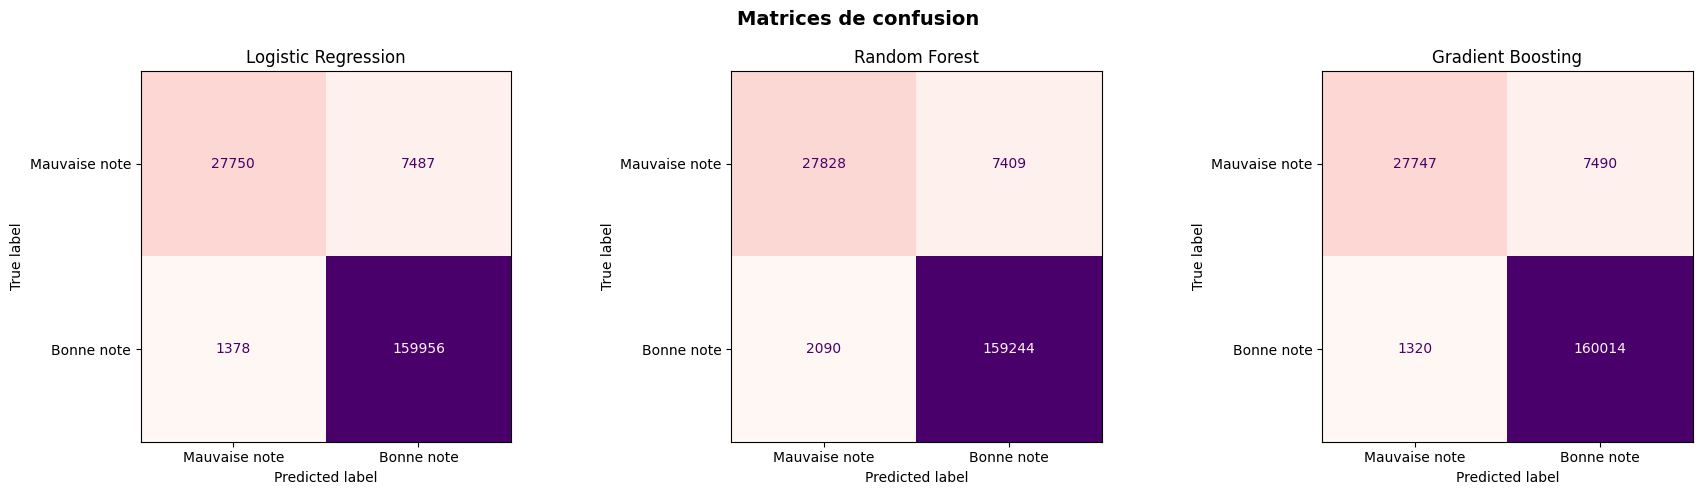

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test)
}

for ax, (name, (model, X)) in zip(axes, models.items()):
    y_pred = model.predict(X)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Mauvaise note', 'Bonne note'])
    disp.plot(ax=ax, colorbar=False, cmap='RdPu')
    ax.set_title(name)

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/matrices_confusion.png')
plt.show()

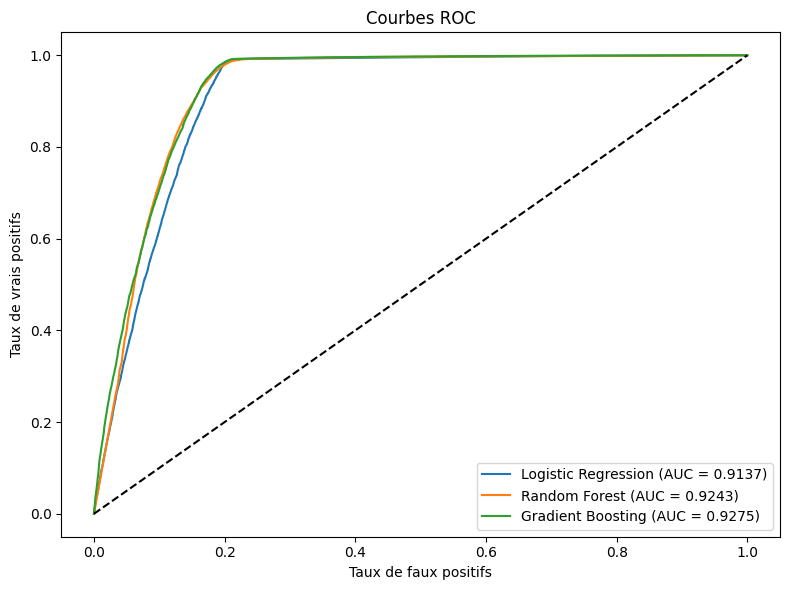

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test)
}

for name, (model, X) in models_roc.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/courbes_roc.png')
plt.show()